In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import torch
import numpy as np
import pandas as pd 
import random
import json
import re

from pathlib import Path

# To set deterministic behaviour:
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  # or ':16:8'
sys.path.append('/Data_large/marine/PythonProjects/MMDET/MyConfigs')

from mmengine.config import Config, DictAction
from mmengine.logging import print_log
from mmengine.registry import RUNNERS
from mmengine.runner import Runner
from mmdet.evaluation import DumpDetResults

from mmdet.utils import setup_cache_size_limit_of_dynamo


def set_seed(seed):
    # Set the seed for generating random numbers in PyTorch
    torch.manual_seed(seed)
    # If using GPUs, ensure that the random numbers are generated the same way
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    
    # Set the seed for generating random numbers in Python
    random.seed(seed)
    
    # Set the seed for generating random numbers in numpy
    np.random.seed(seed)
    
    # Ensure deterministic behavior by setting the flag
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Optionally, set environment variables to ensure reproducibility
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed(42)

def init_cfg(folder):
    cfg = Config.fromfile(f'{folder}/vfnet_r18.py')
    return cfg

def extract_first_band(path):
    # Regular expression to extract the first number after the first 'b'
    match = re.search(r'perfect_b(\d+)', path)

    # Extracted value
    if match:
        first_b_number = match.group(1)
        return int(first_b_number)

def list_weights(folder):
    return [x for x in Path(folder).rglob('*.pth') if 'best' not in str(x)]

def get_weight_b(band_sel):
    weigths = list_weights(f'/Data_large/marine/PythonProjects/MMDET/checkpoints/VENuS/Single/perfect_b{band_sel}')
    assert len(weigths) > 0, 'No weights found'
    weight_path = weigths[0]
    return weight_path


def set_NoiseTesting_config(weight_path, sensor: str, SNR: float, mtf_at_fe: float, Seed: int = 18):
    """
    Set the configuration for noise testing.
    Args:
        weight_path (str): The path to the weight file.
        sensor (str): The sensor: sentinel or venus
        SNR (float): The signal to noise ratio.
        mtf_at_fe (float): The modulation transfer function at the Nyquist frequency.
        Seed (int) : The seed for the random number generator.
    Returns:
        Config: The modified configuration object.
    """
    IMG_SIZE = 2048 # Default
    
    if isinstance(weight_path, str) :
        cfgDir = Path(weight_path).parent
    else:
        cfgDir = weight_path.parent
    
    
    cfg = init_cfg(folder=f'{cfgDir}')
    band_sel = extract_first_band(weight_path.as_posix())
    assert band_sel is not None, f'Band not found in the weight path: {weight_path}'
    assert band_sel in [x for x in range(1,13,1)], f'Band not in the range [1,12]: {band_sel}'
    
    # Modify Config
    CHECKPOINT = weight_path
    cfg.load_from = f"{CHECKPOINT}"
    print(f'Loading from: {CHECKPOINT}')
    cfg.test_dataloader.dataset.pipeline = [{'type': 'SelBandLoader', 'to_float32': True, 'bands_list': [band_sel]},
                        dict(type='LoadAnnotations', with_bbox=True),
                        dict(keep_ratio=False, scale=(IMG_SIZE,IMG_SIZE,), type='Resize'),
                        dict(type='ImageCorruption', sensor=sensor, SNR=SNR, mtf_at_fe=mtf_at_fe), # 'gaussian', 
                        dict(
                            meta_keys=('img_path', 'img_id', 'seg_map_path', 
                                    'height', 'width', 'instances', 'sample_idx', 
                                    'img', 'img_shape', 'ori_shape', 'scale', 'scale_factor', 
                                    'keep_ratio', 'homography_matrix', 'gt_bboxes', 'gt_ignore_flags', 
                                    'gt_bboxes_labels'),
                            type='PackDetInputs'),
                    ]

    work_dir = '/Data_large/marine/PythonProjects/MMDET/studies/tta_study'
    cfg.work_dir = work_dir
    
    # Hook for using the SIoU intestead of the IoU:
    cfg.test_evaluator.type = 'SIoUCocoMetric'
    return cfg

In [3]:
band_sel = 5 # BANDA SELEZIONATA

weigths = list_weights(f'/Data_large/marine/PythonProjects/MMDET/checkpoints/VENuS/Single/perfect_b{band_sel}')
assert len(weigths) > 0, 'No weights found'
weight_path = weigths[0]
cfg = set_NoiseTesting_config(weight_path, sensor='venus', SNR=5, mtf_at_fe = 0.2, Seed=18)

Loading from: /Data_large/marine/PythonProjects/MMDET/checkpoints/VENuS/Single/perfect_b5/18_BS_3_LR_0.0008_ME_30_OPT_SGD/epoch_25.pth


In [4]:
# TEST
runner = RUNNERS.build(cfg)
work_dir = '/Data_large/marine/PythonProjects/MMDET/studies/tta_study'
runner.test_evaluator.metrics.append(DumpDetResults(out_file_path=f'{work_dir}/test_result/test.pkl'))
output_test_data = runner.test()

09/14 10:40:52 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.8.19 | packaged by conda-forge | (default, Mar 20 2024, 12:47:35) [GCC 12.3.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 18
    GPU 0: NVIDIA A100-SXM4-40GB
    CUDA_HOME: /usr/local/cuda-11.4
    NVCC: Cuda compilation tools, release 11.4, V11.4.152
    GCC: gcc (Ubuntu 9.4.0-1ubuntu1~20.04.2) 9.4.0
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;

/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


09/14 10:40:58 - mmengine - INFO - Epoch(test) [ 3/57]    eta: 0:00:52  time: 0.9681  data_time: 0.3346  memory: 1112  
09/14 10:40:59 - mmengine - INFO - Epoch(test) [ 4/57]    eta: 0:00:39  time: 0.7521  data_time: 0.2538  memory: 1112  
09/14 10:40:59 - mmengine - INFO - Epoch(test) [ 5/57]    eta: 0:00:33  time: 0.6382  data_time: 0.2221  memory: 1112  
09/14 10:40:59 - mmengine - INFO - Epoch(test) [ 6/57]    eta: 0:00:28  time: 0.5598  data_time: 0.1986  memory: 1112  
09/14 10:40:59 - mmengine - INFO - Epoch(test) [ 7/57]    eta: 0:00:25  time: 0.5059  data_time: 0.1833  memory: 1112  
09/14 10:40:59 - mmengine - INFO - Epoch(test) [ 8/57]    eta: 0:00:23  time: 0.4700  data_time: 0.1767  memory: 1112  
09/14 10:41:00 - mmengine - INFO - Epoch(test) [ 9/57]    eta: 0:00:20  time: 0.4373  data_time: 0.1672  memory: 1112  
09/14 10:41:00 - mmengine - INFO - Epoch(test) [10/57]    eta: 0:00:19  time: 0.4163  data_time: 0.1646  memory: 1112  
09/14 10:41:00 - mmengine - INFO - Epoch

# Cycle Loop

The maximum severity is 0.3. 

In [26]:
Results = {'Band':[], 'SNR':[], 'MTF':[], 'Precision':[], 'Recall':[], 'F1':[]}

SENSOR = 'venus'
BAND = 10 if SENSOR == 'venus' else 8
mtf_tgt = 0.2 if SENSOR == 'venus' else 0.3


SNR = 174 # Nominal SNR --> for S-2 at B8: 174 | for VENµS: 100. 
SNR_levels = np.geomspace(SNR, 1, 20)

for mtf_tgt in [0.2, 0.1, 0.05, 0.01, 0.001]:
    for SNR in SNR_levels:
        # TODO: Update weight path according to band_selected.
        weight_path = get_weight_b(BAND)
        cfg = set_NoiseTesting_config(weight_path, sensor=SENSOR, SNR=SNR, mtf_at_fe = mtf_tgt, Seed=18)

        # Run the test
        runner = RUNNERS.build(cfg)
        work_dir = '/Data_large/marine/PythonProjects/MMDET/studies/tta_study'
        runner.test_evaluator.metrics.append(DumpDetResults(out_file_path=f'{work_dir}/test_result/test.pkl'))
        output_test_data = runner.test()
        
        ####### Save the results:
        P = output_test_data['coco/bbox_mAP']
        R = output_test_data['coco/bbox_AR@100']
        
        Results['Band'].append(BAND)
        Results['SNR'].append(SNR)
        Results['MTF'].append(mtf_tgt)
        
        Results['Precision'].append(P)
        Results['Recall'].append(R)
        try:
            F1 = 2 * (P * R) / (P + R)
        except ZeroDivisionError:
            F1 = 0
        Results['F1'].append(F1)

Loading from: /Data_large/marine/PythonProjects/MMDET/checkpoints/VENuS/Single/perfect_b10/18_BS_3_LR_0.0008_ME_30_OPT_SGD/epoch_30.pth
09/14 12:42:00 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.8.19 | packaged by conda-forge | (default, Mar 20 2024, 12:47:35) [GCC 12.3.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 18
    GPU 0: NVIDIA A100-SXM4-40GB
    CUDA_HOME: /usr/local/cuda-11.4
    NVCC: Cuda compilation tools, release 11.4, V11.4.152
    GCC: gcc (Ubuntu 9.4.0-1ubuntu1~20.04.2) 9.4.0
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (us

/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


09/14 12:42:00 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
09/14 12:42:00 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
(LOWEST      ) EarlyStoppingHook                  
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_i

/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


09/14 12:42:53 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
09/14 12:42:53 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
(LOWEST      ) EarlyStoppingHook                  
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_i

...

09/14 13:38:55 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
09/14 13:38:55 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
(LOWEST      ) EarlyStoppingHook                  
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_i

/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


09/14 13:39:52 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
09/14 13:39:52 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
(LOWEST      ) EarlyStoppingHook                  
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_i

/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


09/14 13:40:46 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
09/14 13:40:46 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
(LOWEST      ) EarlyStoppingHook                  
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_i

In [24]:
pd.DataFrame(Results).to_pickle(f'venus_SNR_study_b{BAND}.pkl')

In [ ]:
Results = {'Band':[], 'SNR':[], 'MTF':[], 'Precision':[], 'Recall':[], 'F1':[]}

SENSOR = 'sentinel'
BAND = 10 if SENSOR == 'venus' else 8
mtf_tgt = 0.2 if SENSOR == 'venus' else 0.3


SNR = 174 # Nominal SNR --> for S-2 at B8: 174 | for VENµS: 100. 
SNR_levels = np.geomspace(SNR, 1, 20)

for SNR in SNR_levels:
    # TODO: Update weight path according to band_selected.
    weight_path = '/Data_large/marine/PythonProjects/MMDET/checkpoints/Sentinel/Special/BS_4/LR_0.0005/IMG_2048/BANDS__b8/42_Optim_SGD/epoch_130.pth'
    cfg = set_NoiseTesting_config(weight_path, sensor=SENSOR, SNR=SNR, mtf_at_fe = mtf_tgt, Seed=18)

    # Run the test
    runner = RUNNERS.build(cfg)
    work_dir = '/Data_large/marine/PythonProjects/MMDET/studies/tta_study'
    runner.test_evaluator.metrics.append(DumpDetResults(out_file_path=f'{work_dir}/test_result/test.pkl'))
    output_test_data = runner.test()
    
    ####### Save the results:
    P = output_test_data['coco/bbox_mAP']
    R = output_test_data['coco/bbox_AR@100']
    
    Results['Band'].append(BAND)
    Results['SNR'].append(SNR)
    Results['MTF'].append(mtf_tgt)
    
    Results['Precision'].append(P)
    Results['Recall'].append(R)
    try:
        F1 = 2 * (P * R) / (P + R)
    except ZeroDivisionError:
        F1 = 0
    Results['F1'].append(F1)

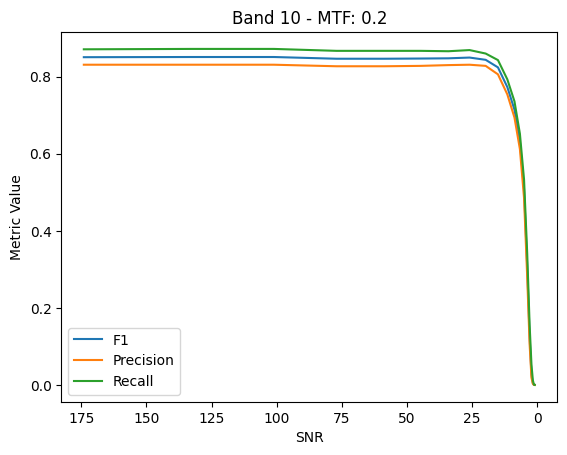

In [25]:
import matplotlib.pyplot as plt

ax = pd.DataFrame(Results).plot(x='SNR', y=['F1', 'Precision', 'Recall'], title=f'Band {BAND} - MTF: {mtf_tgt}')
ax.invert_xaxis()
ax.set_ylabel('Metric Value')

plt.show()

In [6]:
pd.DataFrame(Results).to_pickle('/Data_large/marine/PythonProjects/MMDET/notebooks/plotters/VENuS/TTA_OpticalModel.pkl')

# Plot

In [9]:
Spike = pd.read_pickle('/Data_large/marine/PythonProjects/MMDET/notebooks/plotters/VENuS/TTA_SpikeNoise.pkl')
Guass = pd.read_pickle('/Data_large/marine/PythonProjects/MMDET/notebooks/plotters/VENuS/TTA_GaussianNoise.pkl')

In [ ]:
import pandas as pd
from style import set_style
from matplotlib import pyplot as plt

# Set the style for the plots
set_style(scale_factor=.9, fontsize=9)

# Assuming Results is a dictionary or a similar data structure from which a DataFrame is created.
df = pd.DataFrame(Results)

def get_metrics_x_band(df, band):
    """
    Filter the DataFrame based on the specified band.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    band (int): The band value to filter the DataFrame by.

    Returns:
    pd.DataFrame: The filtered DataFrame containing only the data for the specified band.
    """
    return df[df['Band'] == band]

# Function to normalize the 'Severity' column
def normalize_column(column):
    """
    Normalize the values in a given pandas Series using min-max normalization.

    Parameters:
    column (pd.Series): The column to be normalized.

    Returns:
    pd.Series: The normalized column.
    """
    return (column - column.min()) / (column.max() - column.min())

# Plotting
fig = plt.figure(figsize=(12, 4))  # Adjust the figure size

# Loop through each band
for idx, band in enumerate(range(1, 13)):
    plt.subplot(2, 6, band)
    plt.title('($B_{'+str(band)+'}$)', x=0.1, y=0.85, fontdict={'fontsize': 9})
    
    # Retrieve and normalize data for Spike
    b_spike = get_metrics_x_band(Spike, band)
    x_spike = normalize_column(b_spike['Severity']).to_numpy()  # Normalized Severity for Spike
    y1_spike = b_spike['Precision'].to_numpy()
    y2_spike = b_spike['Recall'].to_numpy()
    y3_spike = b_spike['F1'].to_numpy()
    
    # Plot Spike data
    plt.plot(x_spike, y1_spike, label=f'$Precision$', linestyle='--', color='red')
    plt.plot(x_spike, y2_spike, label=f'$Recall$', linestyle='--', color='blue')
    plt.plot(x_spike, y3_spike, label=f'$F-1 Score$', linestyle='--', color='green')
    
    # Retrieve and normalize data for Guass
    b_guass = get_metrics_x_band(Guass, band)
    x_guass = normalize_column(b_guass['Severity']).to_numpy()  # Normalized Severity for Guass
    y1_guass = b_guass['Precision'].to_numpy()
    y2_guass = b_guass['Recall'].to_numpy()
    y3_guass = b_guass['F1'].to_numpy()
    
    # Plot Guass data
    plt.plot(x_guass, y1_guass, label=f'$Precision$', linestyle='-', color='red')
    plt.plot(x_guass, y2_guass, label=f'$Recall$', linestyle='-', color='blue')
    plt.plot(x_guass, y3_guass, label=f'$F-1 Score$', linestyle='-', color='green')
    
    # Set labels
    if idx in [0, 6]:
        plt.ylabel('Metric Value')
    if idx in [6, 7, 8, 9, 10, 11]:
        plt.xlabel('Severity [$\sigma$]')
    
    # Set limits and legend
    plt.ylim(0, 1)
    plt.xlim(0, 1)

plt.legend(loc='center', bbox_to_anchor=(-3.05, 2.4), ncol=6)

plt.tight_layout()
plt.savefig('/Data_large/marine/PythonProjects/MMDET/plots/SpikeVenus_normalized.png')
plt.show()
